# Unfair ToS Clause Detector — Stages 1 + 2 (combined)

**EDA + TF-IDF/Logistic Regression baseline in one Colab session.** Everything runs in-memory and writes to the Colab VM's local disk — no uploading/downloading files between steps. Run All (Runtime → Run all) and read the output as it goes.

Runtime: CPU is fine for this notebook (no DistilBERT yet — that's a separate, GPU notebook).

At the end, this notebook zips up everything worth keeping (`data/processed/`, `models/baseline_logreg.joblib`) into one download, since Colab wipes local disk when the runtime disconnects.

## 0. Setup

In [1]:
!pip install -q datasets pandas scikit-learn matplotlib seaborn joblib

In [2]:
import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import f1_score, classification_report

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

CATEGORIES = [
    "Limitation of liability", "Unilateral termination", "Unilateral change",
    "Content removal", "Contract by using", "Choice of law",
    "Jurisdiction", "Arbitration",
]

os.makedirs("data/processed", exist_ok=True)
os.makedirs("models", exist_ok=True)

---
# Part A — EDA
## A1. Load the dataset and build the multi-hot label matrix

`coastalcph/lex_glue` (`unfair_tos` config), stored as Parquet on the Hub — no `trust_remote_code` needed. Splits are **chronological, not random**: train (2006–2016), validation (2017), test (2017). Use as-is to stay comparable with published LexGLUE results.

In [3]:
raw = load_dataset("coastalcph/lex_glue", "unfair_tos")
raw

README.md:   0%|          | 0.00/34.1k [00:00<?, ?B/s]

unfair_tos/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  501kB            

unfair_tos/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

unfair_tos/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  147kB            

unfair_tos/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

unfair_tos/validation-00000-of-00001.par(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5532 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1607 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2275 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 5532
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 1607
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 2275
    })
})

In [4]:
def to_frame(split):
    df = split.to_pandas()
    for i, cat in enumerate(CATEGORIES):
        df[cat] = df["labels"].apply(lambda ls: int(i in ls))
    df["is_unfair"] = df[CATEGORIES].sum(axis=1) > 0
    df["word_count"] = df["text"].str.split().apply(len)
    return df

train_df = to_frame(raw["train"])
val_df   = to_frame(raw["validation"])
test_df  = to_frame(raw["test"])

print(f"train: {len(train_df):,} sentences")
print(f"val:   {len(val_df):,} sentences")
print(f"test:  {len(test_df):,} sentences")
train_df.head()

train: 5,532 sentences
val:   2,275 sentences
test:  1,607 sentences


,text,labels,Limitation of liability,Unilateral termination,Unilateral change,Content removal,Contract by using,Choice of law,Jurisdiction,Arbitration,is_unfair,word_count
0,"notice to california subscribers : you may cancel your subscription , without penalty or obligation , at any time pr...",[],0,0,0,0,0,0,0,0,False,33
1,"if you subscribed using your apple id , refunds are handled by apple , not tinder . \n",[],0,0,0,0,0,0,0,0,False,17
2,"if you wish to request a refund , please visit https://getsupport.apple.com . \n",[],0,0,0,0,0,0,0,0,False,12
3,if you subscribed using your google play store account or through tinder online : contact customer support \n,[],0,0,0,0,0,0,0,0,False,17
4,key changes in this version : we 've included a legal notice required under california law regarding refunds and upd...,[],0,0,0,0,0,0,0,0,False,28


## A2. Category frequency counts

In [5]:
def category_counts(df, split_name):
    counts = df[CATEGORIES].sum().sort_values(ascending=False)
    pct = (counts / len(df) * 100).round(2)
    out = pd.DataFrame({"count": counts, "pct_of_sentences": pct})
    out.index.name = split_name
    return out

counts_train = category_counts(train_df, "train")
print(f"Neutral (no category) sentences in train: {(~train_df['is_unfair']).sum():,} "
      f"({(~train_df['is_unfair']).mean()*100:.1f}%)")
counts_train

Neutral (no category) sentences in train: 4,902 (88.6%)


,count,pct_of_sentences
train,,
Limitation of liability,191,3.45
Unilateral termination,139,2.51
Unilateral change,122,2.21
Contract by using,76,1.37
Content removal,73,1.32
Choice of law,39,0.70
Jurisdiction,34,0.61
Arbitration,28,0.51


/tmp/ipykernel_696/2197310618.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_train["count"].values, y=order, ax=ax, palette="viridis")


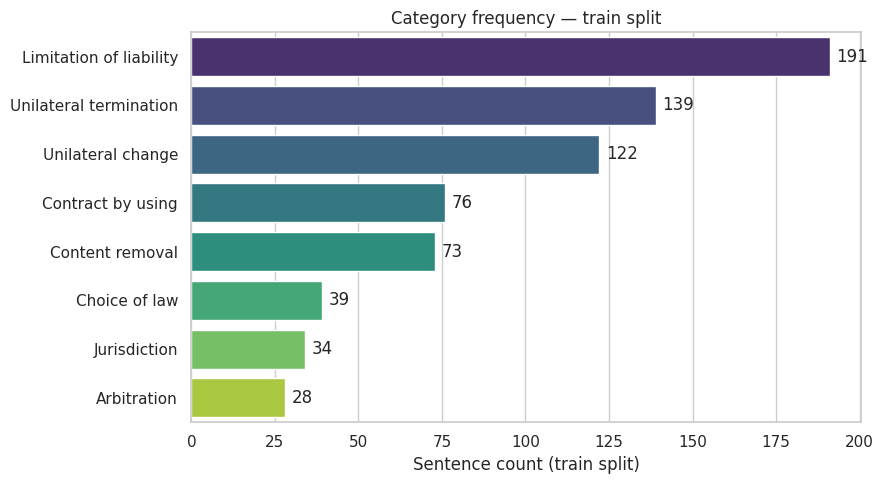

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
order = counts_train.index
sns.barplot(x=counts_train["count"].values, y=order, ax=ax, palette="viridis")
ax.set_xlabel("Sentence count (train split)")
ax.set_ylabel("")
ax.set_title("Category frequency — train split")
for i, v in enumerate(counts_train["count"].values):
    ax.text(v + 2, i, str(int(v)), va="center")
plt.tight_layout()
plt.show()

## A3. Category co-occurrence heatmap

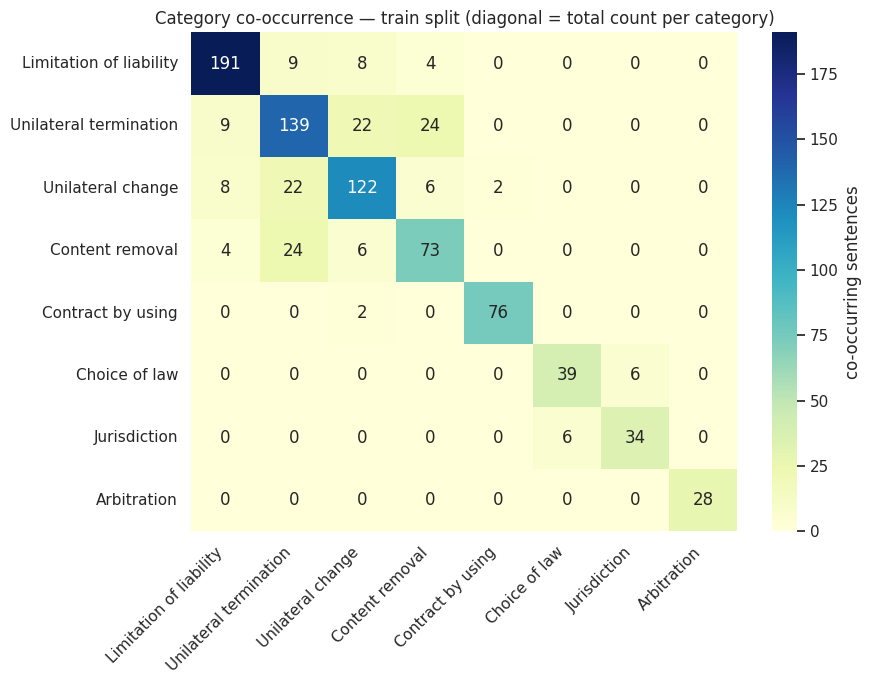

In [7]:
label_matrix = train_df[CATEGORIES].values
co_occurrence = label_matrix.T @ label_matrix
co_df = pd.DataFrame(co_occurrence, index=CATEGORIES, columns=CATEGORIES)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(co_df, annot=True, fmt="d", cmap="YlGnBu", ax=ax, cbar_kws={"label": "co-occurring sentences"})
ax.set_title("Category co-occurrence — train split (diagonal = total count per category)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## A4. Sentence length distribution (word count)

count    5532.000000
mean       32.283080
std        24.745549
min         6.000000
25%        17.000000
50%        26.000000
75%        39.000000
max       441.000000
Name: word_count, dtype: float64
  p50: 26 words
  p75: 39 words
  p90: 58 words
  p95: 75 words
  p99: 122 words


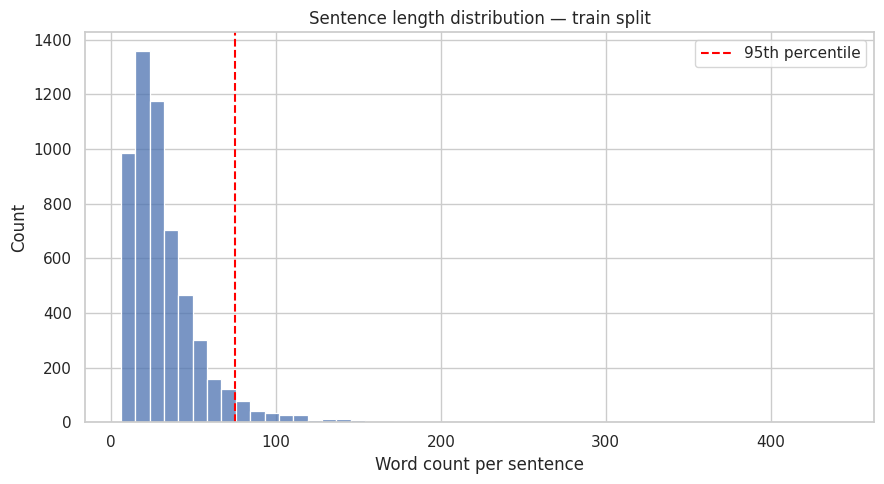

In [8]:
wc = train_df["word_count"]
print(wc.describe())
for p in [50, 75, 90, 95, 99]:
    print(f"  p{p}: {np.percentile(wc, p):.0f} words")

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(wc, bins=50, ax=ax)
ax.axvline(wc.quantile(0.95), color="red", linestyle="--", label="95th percentile")
ax.set_xlabel("Word count per sentence")
ax.set_title("Sentence length distribution — train split")
ax.legend()
plt.tight_layout()
plt.show()

> **max_length note (for the DistilBERT notebook):** subword tokenizers typically run ≈1.3x longer than raw word counts on legal text. Use the 95th/99th percentile above as a floor and round up to a power-of-two-ish value (64/96/128/192).

## A5. Example sentences per category

In [9]:
N_EXAMPLES = 3
for cat in CATEGORIES:
    subset = train_df[train_df[cat] == 1]["text"]
    print(f"\n=== {cat} ({len(subset)} sentences in train) ===")
    for txt in subset.sample(min(N_EXAMPLES, len(subset)), random_state=42):
        print(f"  - {txt.strip()[:220]}")


=== Limitation of liability (191 sentences in train) ===
  - to the extent permissible under applicable law , spotify reserves the right , periodically and at any time , to modify or discontinue , temporarily or permanently , functions and features of the spotify service , with or
  - note that it is your responsibility to be aware of such notices , and you hereby acknowledge and agree that blizzard entertainment shall not be responsible for any damages which may arise from your failure to read and/or
  - as such , we are not liable for any damage or loss caused or alleged to be caused by or in connection with the use of or reliance on any such social networking services .

=== Unilateral termination (139 sentences in train) ===
  - we may suspend , or terminate your access to or use of our services anytime for any reason , such as if you violate the letter or spirit of our terms and polices , or create harm , risk , or possible legal exposure for u
  - violation of these terms of use

## A6. Class imbalance summary

*Fill this in from your own run's output above — don't assume these numbers, read the real ones.*

- **Neutral vs. flagged:** `___%` of train sentences carry zero categories.
- **Most frequent categories:** `___`, `___`.
- **Rarest categories:** `___`, `___` — these will need the lowest decision thresholds later.
- **Co-occurrence:** note the strongest category pairs from the heatmap.
- **Sentence length:** median `___` words, 95th percentile `___` words → informs `max_length` for DistilBERT.

## A7. Save processed splits (stays local to this runtime)

In [10]:
keep_cols = ["text", "labels"] + CATEGORIES + ["is_unfair", "word_count"]

train_df[keep_cols].to_parquet("data/processed/train.parquet", index=False)
val_df[keep_cols].to_parquet("data/processed/val.parquet", index=False)
test_df[keep_cols].to_parquet("data/processed/test.parquet", index=False)

print("Saved processed train/val/test to data/processed/")
print(os.listdir("data/processed"))

Saved processed train/val/test to data/processed/
['test.parquet', 'val.parquet', 'train.parquet']


---
# Part B — Baseline: TF-IDF + Logistic Regression

Uses `train_df`/`val_df` already in memory from Part A — no reload needed. Implements section 5 of the architecture plan.

In [11]:
def build_pipeline(ngram_range=(1, 2), C=1.0, max_features=20000, min_df=2):
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True, ngram_range=ngram_range,
            min_df=min_df, max_features=max_features, sublinear_tf=True,
        )),
        ("clf", OneVsRestClassifier(
            LogisticRegression(class_weight="balanced", max_iter=1000, C=C)
        )),
    ])

X_train, y_train = train_df["text"], train_df[CATEGORIES]
X_val, y_val = val_df["text"], val_df[CATEGORIES]

## B1. Grid search over `ngram_range` and `C`, scored on validation macro-F1

In [12]:
param_grid = {"ngram_range": [(1, 1), (1, 2)], "C": [0.1, 1, 5, 10]}

results = []
t0 = time.time()
for params in ParameterGrid(param_grid):
    pipe = build_pipeline(ngram_range=params["ngram_range"], C=params["C"])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_val)
    macro_f1 = f1_score(y_val, preds, average="macro", zero_division=0)
    micro_f1 = f1_score(y_val, preds, average="micro", zero_division=0)
    results.append({**params, "macro_f1": macro_f1, "micro_f1": micro_f1})
    print(f"{params}  macro_f1={macro_f1:.4f}  micro_f1={micro_f1:.4f}")

print(f"\nGrid search took {time.time()-t0:.1f}s")
results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
results_df

{'C': 0.1, 'ngram_range': (1, 1)}  macro_f1=0.5246  micro_f1=0.5023
{'C': 0.1, 'ngram_range': (1, 2)}  macro_f1=0.5847  micro_f1=0.5617
{'C': 1, 'ngram_range': (1, 1)}  macro_f1=0.5883  micro_f1=0.5798
{'C': 1, 'ngram_range': (1, 2)}  macro_f1=0.6192  micro_f1=0.6114
{'C': 5, 'ngram_range': (1, 1)}  macro_f1=0.6450  micro_f1=0.6513
{'C': 5, 'ngram_range': (1, 2)}  macro_f1=0.6640  micro_f1=0.6621
{'C': 10, 'ngram_range': (1, 1)}  macro_f1=0.6621  micro_f1=0.6735
{'C': 10, 'ngram_range': (1, 2)}  macro_f1=0.6886  micro_f1=0.6871

Grid search took 21.5s


,C,ngram_range,macro_f1,micro_f1
7,10.0,"(1, 2)",0.688554,0.687050
5,5.0,"(1, 2)",0.663957,0.662116
6,10.0,"(1, 1)",0.662060,0.673540
4,5.0,"(1, 1)",0.645005,0.651316
3,1.0,"(1, 2)",0.619217,0.611446
2,1.0,"(1, 1)",0.588309,0.579750
1,0.1,"(1, 2)",0.584700,0.561737
0,0.1,"(1, 1)",0.524628,0.502347


**Reference run (yours should be close — small variation across environments is normal):** `(1,2)` ngrams beat `(1,1)` at every `C`, and macro-F1 was still climbing at `C=10`, the grid's edge — signal to extend the search rather than accept a boundary value.

In [13]:
extended_results = []
for C in [10, 20, 30, 50]:
    pipe = build_pipeline(ngram_range=(1, 2), C=C)
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_val)
    macro_f1 = f1_score(y_val, preds, average="macro", zero_division=0)
    micro_f1 = f1_score(y_val, preds, average="micro", zero_division=0)
    extended_results.append({"C": C, "macro_f1": macro_f1, "micro_f1": micro_f1})
    print(f"C={C}: macro_f1={macro_f1:.4f}  micro_f1={micro_f1:.4f}")

extended_df = pd.DataFrame(extended_results)
extended_df

C=10: macro_f1=0.6886  micro_f1=0.6871
C=20: macro_f1=0.7018  micro_f1=0.7039
C=30: macro_f1=0.7113  micro_f1=0.7094
C=50: macro_f1=0.7097  micro_f1=0.7066


,C,macro_f1,micro_f1
0,10,0.688554,0.687050
1,20,0.701805,0.703911
2,30,0.711302,0.709434
3,50,0.709666,0.706564


**Reference run:** macro-F1 peaked at **C=30** (0.710) then dropped at C=50 (0.704) — a real interior maximum, not a truncated-grid artifact. Pick whichever `C` maximizes macro-F1 in *your* run below — don't hardcode 30 blindly if your numbers differ.

In [14]:
# Pick the best C from the extended search programmatically rather than hardcoding it,
# so this cell stays correct even if your numbers differ slightly from the reference run.
BEST_NGRAM_RANGE = (1, 2)
BEST_C = extended_df.loc[extended_df["macro_f1"].idxmax(), "C"]
print(f"Best C selected: {BEST_C}")

Best C selected: 30


## B2. Fit the best pipeline on train, evaluate on validation

In [15]:
best_pipe = build_pipeline(ngram_range=BEST_NGRAM_RANGE, C=BEST_C)
best_pipe.fit(X_train, y_train)

preds = best_pipe.predict(X_val)
report_text = classification_report(y_val, preds, target_names=CATEGORIES, zero_division=0)
report_dict = classification_report(y_val, preds, target_names=CATEGORIES, zero_division=0, output_dict=True)

print(report_text)
print(f"Validation macro-F1: {f1_score(y_val, preds, average='macro', zero_division=0):.4f}")
print(f"Validation micro-F1: {f1_score(y_val, preds, average='micro', zero_division=0):.4f}")

                         precision    recall  f1-score   support

Limitation of liability       0.61      0.76      0.68        67
 Unilateral termination       0.71      0.80      0.75        59
      Unilateral change       0.56      0.68      0.61        28
        Content removal       0.74      0.62      0.68        32
      Contract by using       0.61      0.94      0.74        18
          Choice of law       0.93      0.72      0.81        18
           Jurisdiction       0.84      0.89      0.86        18
            Arbitration       0.56      0.56      0.56         9

              micro avg       0.67      0.76      0.71       249
              macro avg       0.69      0.75      0.71       249
           weighted avg       0.68      0.76      0.71       249
            samples avg       0.08      0.08      0.08       249

Validation macro-F1: 0.7113
Validation micro-F1: 0.7094


## B3. Save the fitted pipeline

In [16]:
joblib.dump(best_pipe, "models/baseline_logreg.joblib")
print("Saved to models/baseline_logreg.joblib")

Saved to models/baseline_logreg.joblib


## B4. Which categories does the baseline struggle with?

In [17]:
per_cat_f1 = {cat: report_dict[cat]["f1-score"] for cat in CATEGORIES}
ranked = sorted(per_cat_f1.items(), key=lambda x: x[1])

print("Baseline categories ranked worst -> best by validation F1:")
for cat, f1 in ranked:
    support = int(report_dict[cat]["support"])
    print(f"  {f1:.3f}  {cat}  (support={support})")

Baseline categories ranked worst -> best by validation F1:
  0.556  Arbitration  (support=9)
  0.613  Unilateral change  (support=28)
  0.675  Limitation of liability  (support=67)
  0.678  Content removal  (support=32)
  0.739  Contract by using  (support=18)
  0.752  Unilateral termination  (support=59)
  0.812  Choice of law  (support=18)
  0.865  Jurisdiction  (support=18)


**Reference run — weakest three:** Arbitration (F1 0.56, only 9 val examples — noisy), Unilateral change (F1 0.61, plausibly confused with Unilateral termination — check the co-occurrence heatmap above), Limitation of liability (F1 0.67, largest category so its errors weigh heavily on the aggregate averages). Compare against your own ranked list — note the categories with the smallest support are the noisiest and worth re-checking against the Stage 4 test-set numbers before drawing conclusions.

**Stage 3 comparison point:** if DistilBERT doesn't clearly beat this baseline on your weakest categories specifically, that's a more interesting write-up finding than an aggregate macro-F1 delta — it suggests the transformer isn't getting an edge from context/word-order on the categories where a bag-of-words model struggles most.

---
# Part C — Download everything worth keeping

Colab wipes local disk when the runtime disconnects. Run this cell once, then keep the downloaded zip somewhere durable (or push it to GitHub / Drive) — the DistilBERT notebook and every later stage need `data/processed/*.parquet`, and the backend needs `models/baseline_logreg.joblib`.

In [18]:
import shutil
shutil.make_archive("stage1_2_outputs", "zip", ".", "data")
# also fold in models/ into the same archive
import zipfile
with zipfile.ZipFile("stage1_2_outputs.zip", "a") as zf:
    zf.write("models/baseline_logreg.joblib", arcname="models/baseline_logreg.joblib")

print("Bundled: data/processed/{train,val,test}.parquet + models/baseline_logreg.joblib")

try:
    from google.colab import files
    files.download("stage1_2_outputs.zip")
except ImportError:
    print("Not running in Colab — find stage1_2_outputs.zip in the working directory.")

Bundled: data/processed/{train,val,test}.parquet + models/baseline_logreg.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>